# Один патч: от oracle feature-delta к компоненте, доступной по одному изображению

Этот ноутбук фиксирует текущую постановку для **одного патча и одного детектора**. Его цель — не переобучать модели, а прозрачно показать:

1. что именно называется feature-delta;
2. как из неё строится oracle-компонента;
3. чем реальный one-image режим отличается от oracle;
4. какие величины поступают student-модели на вход и что она предсказывает;
5. какой потолок даёт oracle и какую часть этого потолка уже достигает leak-free механизм.

## 1. Oracle-режим: истинная clean → patched дельта

Пусть $H_l^c$ и $H_l^p$ — входные карты признаков Detect head уровня $l$ для чистого и соответствующего ему patched-изображения. Тогда истинная feature-delta:

$$
\Delta_l = H_l^p-H_l^c.
$$

Для заранее известного целевого объекта собирается резерв его pre-NMS кандидатов. В локальных окнах вокруг их routes вычисляется joint-выход

$$
f(H)=
\begin{bmatrix}
\text{person logits выбранных кандидатов}\\
\text{decoded IoU выбранных кандидатов с clean target box}
\end{bmatrix},
$$

и его path-averaged Jacobian $J_l=\partial f/\partial H_l$. После SVD строки $J_l$ задают функциональное подпространство с ортонормированным базисом $B_l$. Проекция реальной дельты на него:

$$
C_l^{oracle}
=
P_l\Delta_l
=
B_l^\top(B_l\Delta_l).
$$

Это и есть oracle joint-компонента. Её относительная энергия:

$$
\rho_J
=
\frac{\sum_l\lVert C_l^{oracle}\rVert_2^2}
{\sum_l\lVert\Delta_l\rVert_2^2}.
$$

Причинная проверка выполняется в обе стороны:

$$
H_l^{repair}=H_l^p-C_l^{oracle},
\qquad
H_l^{transplant}=H_l^c+C_l^{oracle}.
$$

- `repair` проверяет **необходимость**: появится ли скрытый объект после удаления компоненты;
- `transplant` проверяет **достаточность**: скроется ли объект после переноса компоненты в clean-состояние.

Oracle использует информацию, которой нет на практическом инференсе: clean-пару, clean target box и соответствие target candidates. Поэтому его результат — причинный потолок, а не готовая защита.

## 2. Реальный one-image режим

На инференсе доступно только одно изображение $z$. Оно проходит через детектор и даёт $H_l(z)$. Вместо clean-пары заранее, **только на отдельном clean train/reference split**, оцениваются channel-wise статистики $\mu_{l,c}$ и $\sigma_{l,c}$:

$$
z_k=\frac{H_k(z)-\mu_k}{\sigma_k}.
$$

Из наблюдаемых pre-NMS кандидатов строятся кластеры возможных объектов. Для каждого кластера $\mathcal C$ берётся агрегированный функциональный objective (score + geometry), и одним backward вычисляется локальная чувствительность:

$$
g_k=\frac{\partial F_{\mathcal C}}{\partial H_k(z)}.
$$

Для координаты $k$ student получает только наблюдаемые признаки:

$$
\phi_k=
\left[
z_k,\ l,\ c,\ y,\ x,\ g_k,\ z_kg_k
\right],
$$

а расширенные варианты также используют локальное среднее, локальное стандартное отклонение и отличие центра от окружения. Student обучается приближать oracle teacher:

$$
\widehat C_k=s_\psi(\phi_k)
\approx C_k^{oracle}.
$$

После ранжирования кластеров и отбора координат применяется:

$$
H_k^{corrected}=H_k(z)-\widehat C_k.
$$

Ключевое различие: в oracle $\Delta=H^p-H^c$ измеряется напрямую; в реальном режиме **истинная $\Delta$ неизвестна**. Student не вычитает наблюдаемое изображение из его clean-пары — он предсказывает нужную компоненту по текущим активациям, population reference и градиентам.

In [1]:
from pathlib import Path
import json
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

HERE = Path.cwd().resolve()
if HERE.name != "CandidateRoutingAndAttackPath":
    HERE = HERE / "CandidateRoutingAndAttackPath"
assert HERE.exists(), f"Не найдена папка CandidateRoutingAndAttackPath: {HERE}"

ORACLE = HERE / "followup_outputs" / "full_success_2a6617f59d1bed77"
STUDENT = HERE / "large_component_student_outputs" / "large_student_b1ec65f6d9fcc5d5"
LEAK_FREE = HERE / "leak_free_defense_outputs" / "leak_free_593effe4b13ad110"
LEVEL_FINAL = HERE / "level_ablation_outputs" / "level_ablation_4f69509f480eeab3"
EXPANDED_FINAL = HERE / "no_iou_expansion_outputs" / "no_iou_expansion_ebb0720a5fc75739"

for path in [ORACLE, STUDENT, LEAK_FREE, LEVEL_FINAL, EXPANDED_FINAL]:
    assert path.exists(), f"Не найден обязательный артефакт: {path}"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10.5, 5.5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 10.5,
})
BLUE, GREEN, ORANGE, RED, PURPLE, GRAY = (
    "#457B9D", "#2A9D8F", "#F4A261", "#E76F51", "#7B2CBF", "#6C757D"
)

oracle_rows = pd.read_csv(ORACLE / "joint_functional_rows.csv")
oracle_summary = pd.read_csv(ORACLE / "joint_functional_summary.csv")
student_summary = pd.read_csv(STUDENT / "summary.csv")
leak_free_summary = pd.read_csv(LEAK_FREE / "summary.csv")
level_final = pd.read_csv(LEVEL_FINAL / "final_summary.csv")
expanded_final = pd.read_csv(EXPANDED_FINAL / "summary.csv")

print("Артефакты загружены:")
print(f"  oracle rows:       {len(oracle_rows):,}")
print(f"  student conditions:{len(student_summary):,}")
print(f"  leak-free rows:    {len(leak_free_summary):,}")

Артефакты загружены:
  oracle rows:       1,400
  student conditions:10
  leak-free rows:    4


## 3. Численный oracle-пример из эксперимента

Ниже автоматически выбирается один реально скрытый пример. Для него показываются исходное состояние, repair и обратный transplant.

Читать таблицу следует так:

- `component_energy_fraction = 0.003782` означает $0.3782\%$ полной энергии feature-delta;
- `post_target_conf < 0.25` означает, что целевая детекция скрыта;
- `target_detected = 1` означает восстановление объекта после обычных decode, threshold и NMS.

In [2]:
example_id = (
    oracle_rows.loc[
        oracle_rows["analysis_group"].eq("hidden_low_conf_match"),
        "example_id",
    ]
    .drop_duplicates()
    .iloc[0]
)

conditions = [
    "none",
    "score_rowspace",
    "geometry_rowspace",
    "joint_rowspace",
    "joint_null",
    "full_candidate_windows",
]
example = oracle_rows[
    oracle_rows["example_id"].eq(example_id)
    & oracle_rows["condition"].isin(conditions)
].copy()
example["energy_percent"] = 100 * example["component_energy_fraction"]

display(
    example[
        [
            "direction",
            "condition",
            "post_target_conf",
            "post_target_iou",
            "target_detected",
            "energy_percent",
        ]
    ]
    .sort_values(["direction", "energy_percent"])
    .style.format({
        "post_target_conf": "{:.4f}",
        "post_target_iou": "{:.4f}",
        "energy_percent": "{:.4f}%",
    })
)

base = example[
    example["direction"].eq("repair_patched")
    & example["condition"].eq("none")
].iloc[0]
joint_repair = example[
    example["direction"].eq("repair_patched")
    & example["condition"].eq("joint_rowspace")
].iloc[0]
joint_transplant = example[
    example["direction"].eq("transplant_clean")
    & example["condition"].eq("joint_rowspace")
].iloc[0]

print(f"example_id = {example_id}")
print(f"patched baseline confidence = {base.post_target_conf:.6f} < 0.25")
print(
    "oracle joint energy = "
    f"{joint_repair.component_energy_fraction:.6f} "
    f"= {100 * joint_repair.component_energy_fraction:.4f}%"
)
print(
    "repair: confidence "
    f"{base.post_target_conf:.6f} → {joint_repair.post_target_conf:.6f}"
)
print(
    "transplant into clean: confidence "
    f"→ {joint_transplant.post_target_conf:.6f}; "
    f"detected={int(joint_transplant.target_detected)}"
)

,direction,condition,post_target_conf,post_target_iou,target_detected,energy_percent
700,repair_patched,none,0.1462,0.6315,0,0.0000%
701,repair_patched,score_rowspace,0.8207,0.6603,1,0.0834%
702,repair_patched,geometry_rowspace,0.1009,0.7856,0,0.2979%
703,repair_patched,joint_rowspace,0.7947,0.7883,1,0.3782%
704,repair_patched,joint_null,0.1117,0.7933,0,9.9302%
705,repair_patched,full_candidate_windows,0.9266,1.0000,1,10.3084%
707,transplant_clean,none,0.9266,1.0000,1,0.0000%
708,transplant_clean,score_rowspace,0.1340,0.9823,0,0.0834%
709,transplant_clean,geometry_rowspace,0.9175,0.9346,1,0.2979%
710,transplant_clean,joint_rowspace,0.1117,0.7933,0,0.3782%


example_id = 1e2cd7413bbfbc32
patched baseline confidence = 0.146248 < 0.25
oracle joint energy = 0.003782 = 0.3782%
repair: confidence 0.146248 → 0.794668
transplant into clean: confidence → 0.111661; detected=0


В выбранном примере joint-компонента занимает меньше половины процента энергии, но её удаление поднимает confidence выше порога, а перенос в clean-состояние снова скрывает цель. `joint_null` содержит значительно больше энергии, однако не воспроизводит тот же функциональный эффект. Это и есть причина фокусироваться не на максимальной по энергии части $\Delta$, а на её проекции на score+geometry row space.

## 4. Oracle-метрики на всей причинной подвыборке

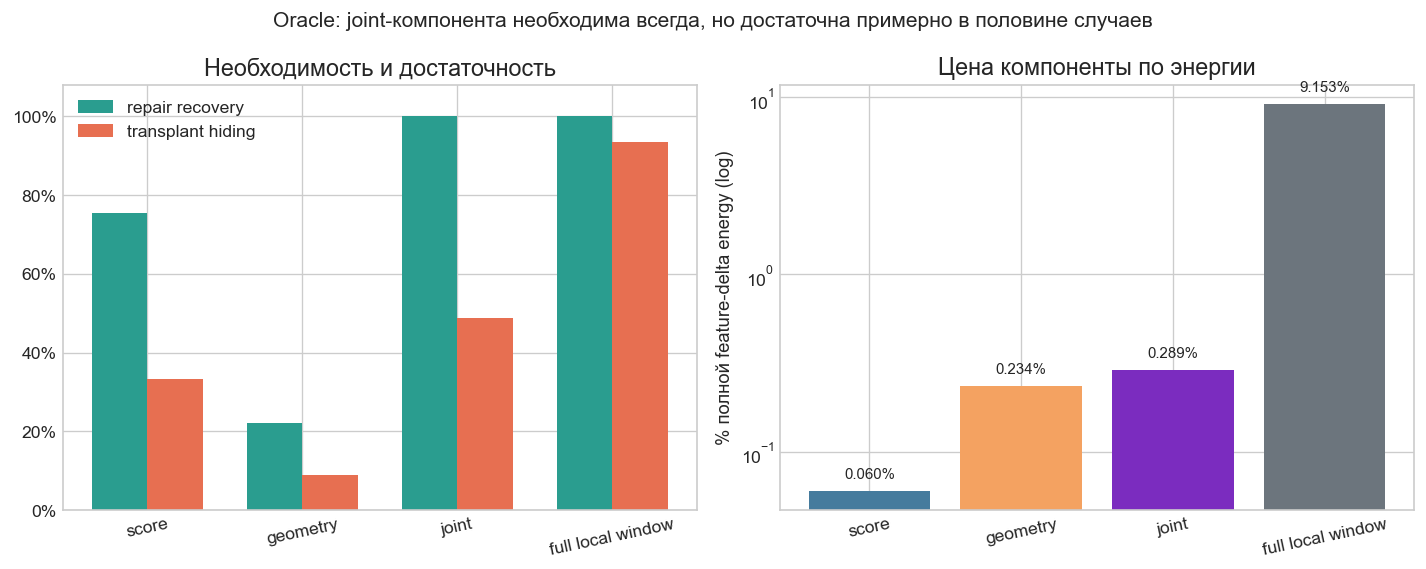

,condition,energy,recovery,sufficiency
0,score,0.000600,75.6%,33.3%
1,geometry,0.002341,22.2%,8.9%
2,joint,0.002893,100.0%,48.9%
3,full local window,0.091533,100.0%,93.3%


In [3]:
oracle_all = oracle_summary[
    oracle_summary["analysis_group"].eq("all")
    & oracle_summary["condition"].isin(
        ["score_rowspace", "geometry_rowspace", "joint_rowspace", "full_candidate_windows"]
    )
].copy()

repair = oracle_all[oracle_all["direction"].eq("repair_patched")].set_index("condition")
transplant = oracle_all[oracle_all["direction"].eq("transplant_clean")].set_index("condition")
order = ["score_rowspace", "geometry_rowspace", "joint_rowspace", "full_candidate_windows"]
labels = ["score", "geometry", "joint", "full local window"]

plot = pd.DataFrame({
    "condition": labels,
    "energy": [repair.loc[c, "mean_component_energy_fraction"] for c in order],
    "recovery": [repair.loc[c, "recovery_rate"] for c in order],
    "sufficiency": [transplant.loc[c, "reproduced_hiding_rate"] for c in order],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(len(plot))
axes[0].bar(x - 0.18, plot["recovery"], width=0.36, color=GREEN, label="repair recovery")
axes[0].bar(x + 0.18, plot["sufficiency"], width=0.36, color=RED, label="transplant hiding")
axes[0].set_xticks(x, plot["condition"], rotation=12)
axes[0].set_ylim(0, 1.08)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("Необходимость и достаточность")
axes[0].legend()

axes[1].bar(plot["condition"], 100 * plot["energy"], color=[BLUE, ORANGE, PURPLE, GRAY])
axes[1].set_yscale("log")
axes[1].set_ylabel("% полной feature-delta energy (log)")
axes[1].set_title("Цена компоненты по энергии")
axes[1].tick_params(axis="x", rotation=12)
for bar, value in zip(axes[1].patches, 100 * plot["energy"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.18,
        f"{value:.3f}%",
        ha="center",
        fontsize=9,
    )

fig.suptitle("Oracle: joint-компонента необходима всегда, но достаточна примерно в половине случаев")
plt.tight_layout()
plt.show()

display(
    plot.style.format({
        "energy": "{:.6f}",
        "recovery": "{:.1%}",
        "sufficiency": "{:.1%}",
    })
)

Главный oracle-результат:

- joint score+geometry component содержит в среднем **0.289%** полной feature-delta energy;
- её удаление восстанавливает **100%** воспроизводимо скрытых целей в этой подвыборке;
- перенос одной только joint-компоненты воспроизводит скрытие примерно в **48.9%** случаев;
- полная локальная дельта вокруг candidate routes почти закрывает sufficiency, значит оставшийся разрыв связан с локальным нелинейным контекстом, а не с глобальной энергией карты.

## 5. Численный пример входа и выхода student

Ниже — сохранённая реальная координата из attacked-only training set. Истинный `teacher_component` был вычислен offline в oracle-режиме; при инференсе student его не получает.

In [4]:
# Зафиксированный compact-пример из coordinate_features.parquet.
# Он нужен только для прозрачного разбора формулы; performance ниже считается
# по независимым полным таблицам, а не по этой строке.
student_example = pd.Series({
    "example_id": "69707d7320a6e366",
    "analysis_group": "hidden_low_conf_match",
    "z": 2.206166,
    "level": 1.0,
    "channel": 0.064579,
    "y": 0.526316,
    "x": 0.473684,
    "gradient": 0.093577,
    "z_gradient": 0.206446,
    "teacher_component": 0.199951,
})

feature_columns = ["z", "level", "channel", "y", "x", "gradient", "z_gradient"]
student_model = joblib.load(LEAK_FREE / "component_student.joblib")
state = np.load(EXPANDED_FINAL / "student_inference_state.npz", allow_pickle=False)
target_scale = float(state["target_scale"])
raw_prediction = float(
    student_model.predict(
        student_example[feature_columns].to_numpy(float).reshape(1, -1)
    )[0]
)
predicted_component = raw_prediction * target_scale

numeric = pd.DataFrame({
    "величина": [
        "z_k",
        "g_k",
        "z_k · g_k",
        "teacher C_k (только обучение/оценка)",
        "student raw output",
        "target scale",
        "predicted Ĉ_k",
    ],
    "значение": [
        student_example["z"],
        student_example["gradient"],
        student_example["z_gradient"],
        student_example["teacher_component"],
        raw_prediction,
        target_scale,
        predicted_component,
    ],
})
display(numeric.style.format({"значение": "{:.6f}"}))

print(
    f"Проверка признака: z_k · g_k = "
    f"{student_example['z']:.6f} × {student_example['gradient']:.6f} "
    f"= {student_example['z'] * student_example['gradient']:.6f}"
)
print(
    f"Предсказание компоненты: {raw_prediction:.6f} × "
    f"{target_scale:.6f} = {predicted_component:.6f}"
)

,величина,значение
0,z_k,2.206166
1,g_k,0.093577
2,z_k · g_k,0.206446
3,teacher C_k (только обучение/оценка),0.199951
4,student raw output,0.396734
5,target scale,0.168564
6,predicted Ĉ_k,0.066875


Проверка признака: z_k · g_k = 2.206166 × 0.093577 = 0.206446
Предсказание компоненты: 0.396734 × 0.168564 = 0.066875


Для этой координаты student правильно предсказывает знак, но недооценивает модуль teacher-компоненты. Это нормально иллюстрирует задачу: нам важна не только coordinate-wise ошибка, а итог после совместного применения тысяч малых поправок, decode и NMS.

## 6. Где теряется oracle-потолок

Следующая диаграмма разделяет две ошибки:

1. **оценка значений** компоненты student-моделью;
2. **локализация поддержки** — какие координаты вообще передать student.

`oracle component` знает и координаты, и значения. `known support student` знает только координаты. `blind oracle values` знает teacher-значения, но применяет их лишь на найденной без координат поддержке. `blind student` не знает ни координат, ни значений.

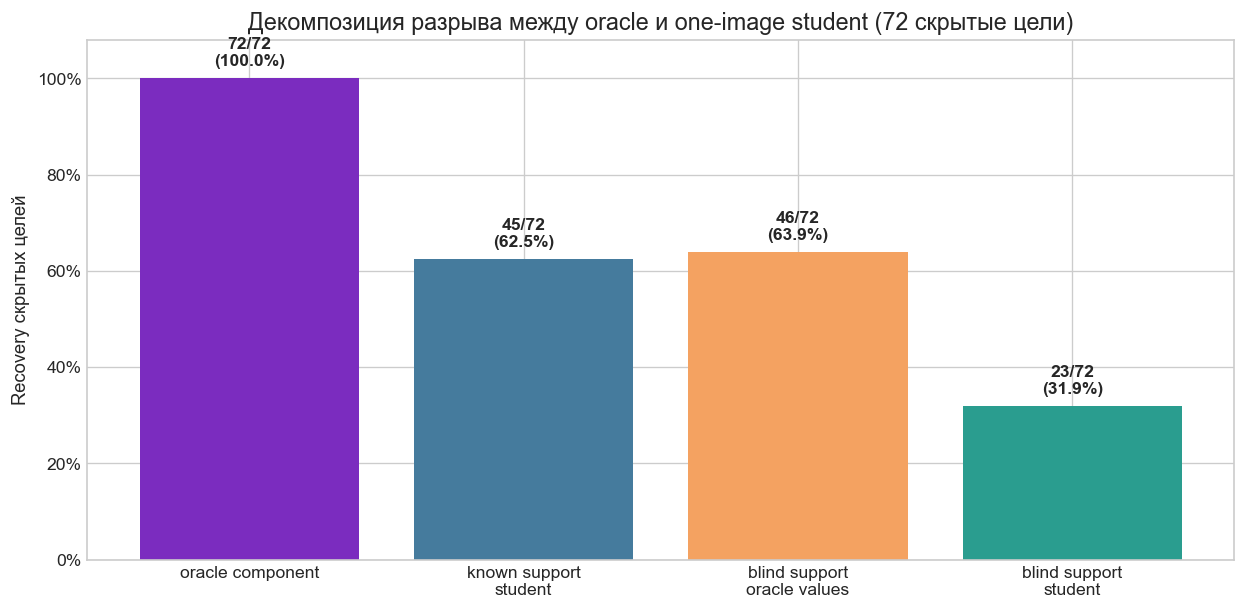

,condition,hidden_n,recovered_n,recovery,support_energy_recall,clean_f1
0,oracle component,72,72,100.0%,100.0%,nan
1,known support student,72,45,62.5%,100.0%,0.9955
2,blind support oracle values,72,46,63.9%,22.8%,nan
3,blind support student,72,23,31.9%,22.8%,0.9937


In [5]:
def student_row(mode, scale=1.0):
    q = student_summary[
        student_summary["mode"].eq(mode)
        & student_summary["correction_scale"].eq(scale)
    ]
    if mode in {"known_support", "blind_support"}:
        q = q[q["feature_set"].eq("functional")]
    return q.iloc[0]

ladder_rows = [
    ("oracle component", student_row("oracle_component")),
    ("known support\nstudent", student_row("known_support")),
    ("blind support\noracle values", student_row("blind_oracle_values")),
    ("blind support\nstudent", student_row("blind_support")),
]
ladder = pd.DataFrame({
    "condition": [name for name, _ in ladder_rows],
    "hidden_n": [int(row.hidden_n) for _, row in ladder_rows],
    "recovered_n": [int(row.hidden_recovered_n) for _, row in ladder_rows],
    "recovery": [row.hidden_recovered_n / row.hidden_n for _, row in ladder_rows],
    "support_energy_recall": [float(row.support_energy_recall) for _, row in ladder_rows],
    "clean_f1": [float(row.clean_full_detection_f1) for _, row in ladder_rows],
})

fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.bar(
    ladder["condition"],
    ladder["recovery"],
    color=[PURPLE, BLUE, ORANGE, GREEN],
)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Recovery скрытых целей")
ax.set_title("Декомпозиция разрыва между oracle и one-image student (72 скрытые цели)")
for bar, n, rate in zip(bars, ladder["recovered_n"], ladder["recovery"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.025,
        f"{n}/72\n({rate:.1%})",
        ha="center",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

display(
    ladder.style.format({
        "recovery": "{:.1%}",
        "support_energy_recall": "{:.1%}",
        "clean_f1": "{:.4f}",
    })
)

Здесь видно, что student при известной поддержке достигает `45/72`, почти совпадая с `blind oracle values = 46/72`. Основной ранний bottleneck — локализация: blind support захватывает лишь около `22.8%` энергии teacher-компоненты, после чего полноценный blind student восстанавливает `23/72`.

## 7. Leak-free механизм на независимых split

В следующем эксперименте:

- student обучен на своём split;
- cluster ranker — на непересекающемся split;
- выбор режима сделан на validation;
- итоговая оценка проведена на fresh-final сценах;
- teacher-компоненты fresh-final не загружались;
- target boxes использовались только после инференса для подсчёта метрик.

,проверка,значение
0,mechanism input,one_image_only
1,paired clean compared at inference,False
2,student and ranker frozen,True
3,validation scenes,200
4,fresh-final scenes,300
5,train ↔ final path overlap,0
6,validation ↔ final overlap,0
7,final teacher records loaded,False
8,selected before final,level_2_only


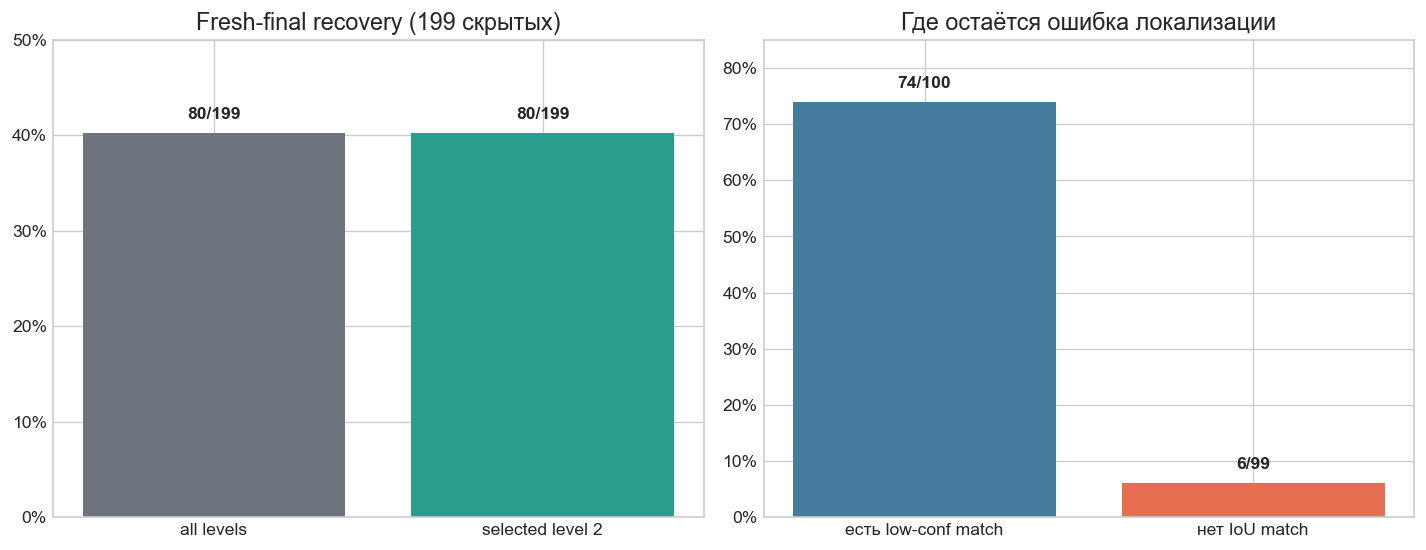

LOCKED fresh-final: recovery = 80/199 (40.2%)
clean full-detection F1 = 0.9933
clean target changes = 0
previously visible patched targets lost = 2


In [6]:
audit = json.loads((LEVEL_FINAL / "leakage_audit.json").read_text())
display(
    pd.DataFrame(
        [
            ("mechanism input", audit["mechanism_input"]),
            ("paired clean compared at inference", audit["patched_clean_pair_compared_by_mechanism"]),
            ("student and ranker frozen", audit["student_and_ranker_frozen"]),
            ("validation scenes", audit["validation_scenes"]),
            ("fresh-final scenes", audit["fresh_final_scenes"]),
            ("train ↔ final path overlap", audit["train_final_path_overlap"]),
            ("validation ↔ final overlap", audit["validation_final_path_overlap"]),
            ("final teacher records loaded", audit["final_teacher_records_loaded"]),
            ("selected before final", audit["condition_selected_before_final_evaluation"]),
        ],
        columns=["проверка", "значение"],
    )
)

final_all = level_final[
    level_final["analysis_group"].eq("all")
    & level_final["condition"].isin(["all_levels", "level_2_only"])
].copy()
final_all["recovery"] = final_all["hidden_recovered_n"] / final_all["hidden_n"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
bars = axes[0].bar(
    ["all levels", "selected level 2"],
    final_all.set_index("condition").loc[["all_levels", "level_2_only"], "recovery"],
    color=[GRAY, GREEN],
)
axes[0].set_ylim(0, 0.5)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("Fresh-final recovery (199 скрытых)")
for bar, condition in zip(bars, ["all_levels", "level_2_only"]):
    row = final_all[final_all["condition"].eq(condition)].iloc[0]
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        row.recovery + 0.015,
        f"{int(row.hidden_recovered_n)}/{int(row.hidden_n)}",
        ha="center",
        fontweight="bold",
    )

groups = level_final[
    level_final["condition"].eq("level_2_only")
    & level_final["analysis_group"].isin(["hidden_low_conf_match", "hidden_no_iou_match"])
].copy()
groups["recovery"] = groups["hidden_recovered_n"] / groups["hidden_n"]
labels = ["есть low-conf match", "нет IoU match"]
bars = axes[1].bar(labels, groups["recovery"], color=[BLUE, RED])
axes[1].set_ylim(0, 0.85)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title("Где остаётся ошибка локализации")
for bar, (_, row) in zip(bars, groups.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        row.recovery + 0.025,
        f"{int(row.hidden_recovered_n)}/{int(row.hidden_n)}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

selected = final_all[final_all["condition"].eq("level_2_only")].iloc[0]
print(
    f"LOCKED fresh-final: recovery = "
    f"{int(selected.hidden_recovered_n)}/{int(selected.hidden_n)} "
    f"({selected.recovery:.1%})"
)
print(f"clean full-detection F1 = {selected.clean_full_detection_f1:.4f}")
print(f"clean target changes = {int(selected.clean_target_change_n)}")
print(f"previously visible patched targets lost = {int(selected.baseline_lost_n)}")

## 8. Последний эксперимент с расширенным discovery

Основной заранее зафиксированный specialist-вариант не улучшил fresh-final результат. В той же таблице `expanded general top-5` достигает более высокого recovery, но это **exploratory comparison**, а не новая честная primary-оценка: выбирать его после просмотра final нельзя. Он становится кандидатом для следующего заранее зафиксированного теста.

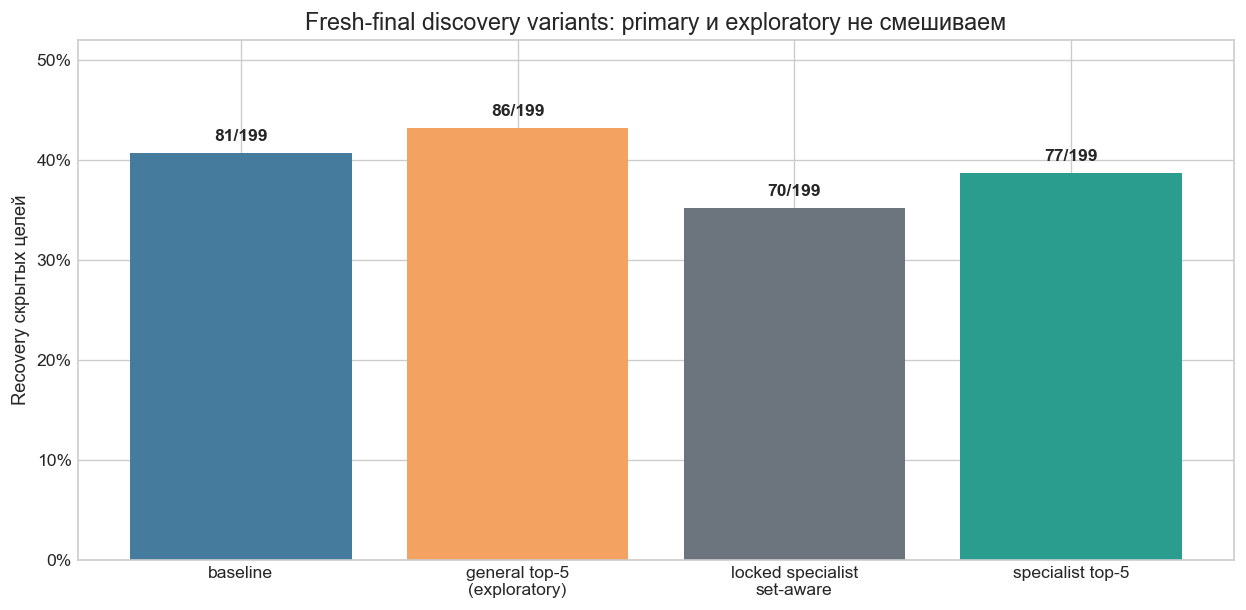

,condition,hidden_n,hidden_recovered_n,recovery,baseline_lost_n,clean_target_change_n,clean_full_detection_f1
0,baseline_pairwise_8k,199,81,40.7%,0,0.000000,0.9929
4,expanded_general_top5_8k,199,86,43.2%,0,0.000000,0.9912
8,expanded_specialist_setaware_top5_8k,199,70,35.2%,0,0.000000,0.9858
12,expanded_specialist_top5_8k,199,77,38.7%,0,0.000000,0.9922


In [7]:
expanded_all = expanded_final[expanded_final["analysis_group"].eq("all")].copy()
expanded_all["recovery"] = (
    expanded_all["hidden_recovered_n"] / expanded_all["hidden_n"]
)
label_map = {
    "baseline_pairwise_8k": "baseline",
    "expanded_general_top5_8k": "general top-5\n(exploratory)",
    "expanded_specialist_top5_8k": "specialist top-5",
    "expanded_specialist_setaware_top5_8k": "locked specialist\nset-aware",
}
expanded_all["label"] = expanded_all["condition"].map(label_map)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
colors = [BLUE, ORANGE, GRAY, GREEN]
bars = ax.bar(expanded_all["label"], expanded_all["recovery"], color=colors)
ax.set_ylim(0, 0.52)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Recovery скрытых целей")
ax.set_title("Fresh-final discovery variants: primary и exploratory не смешиваем")
for bar, (_, row) in zip(bars, expanded_all.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row.recovery + 0.012,
        f"{int(row.hidden_recovered_n)}/{int(row.hidden_n)}",
        ha="center",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

display(
    expanded_all[
        [
            "condition",
            "hidden_n",
            "hidden_recovered_n",
            "recovery",
            "baseline_lost_n",
            "clean_target_change_n",
            "clean_full_detection_f1",
        ]
    ].style.format({
        "recovery": "{:.1%}",
        "clean_full_detection_f1": "{:.4f}",
    })
)

## 9. Что установлено на текущем одном патче

1. **Причинная компонента существует.** Oracle joint-компонента занимает в среднем `0.289%` энергии полной feature-delta и её удаление восстанавливает все воспроизводимо скрытые цели исследованной причинной подвыборки.
2. **Малая энергия не означает малый эффект.** Большой `joint null` содержит намного больше энергии, но действует слабее; важна ориентация относительно score+geometry Jacobian.
3. **Student решает регрессию компоненты, а не детекцию патча.** Его вход — признаки координат текущего endpoint и градиенты; выход — signed correction $\widehat C_k$ в единицах активации Detect head.
4. **На инференсе clean-пары нет.** Population reference фиксируется по отдельному train/reference split; target box и teacher-компонента используются только для обучения или последующей оценки.
5. **Текущий главный bottleneck — discovery/localization.** Когда teacher support известна, student восстанавливает `45/72`; при blind support — `23/72`. На более крупном fresh-final split особенно трудна группа без наблюдаемого IoU match.
6. **Честный fresh-final результат:** выбранный заранее `level_2_only` восстанавливает `80/199 = 40.2%` скрытых целей, не меняет ни одной clean target и сохраняет полный clean output с `F1=0.9933`.
7. **Exploratory направление:** general top-5 discovery даёт `86/199 = 43.2%`, но это нужно подтвердить на новом, ещё не просмотренном split.

### Ограничения

- Пока проверены один detector family и один основной патч.
- Oracle и real метрики относятся к разным экспериментальным подвыборкам и не должны сравниваться как paired значения.
- Target-specific recovery измеряет заранее выбранного человека; full-detection F1 отдельно контролирует побочные изменения всего выхода.
- Следующий универсальный тест должен заранее зафиксировать механизм и проверить его на нескольких патчах, положениях и независимых изображениях.